
# 1D Heat Diffusion: Analytical → FDM → Machine Learning (PINN)

This notebook solves the 1D heat (diffusion) equation

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \qquad x \in [0, L],\ t \in [0, T]$$

with Dirichlet boundary conditions $u(0,t) = g_0$, $u(L,t) = g_L$ and initial condition $u(x,0) = f(x)$,
using **three** approaches so you can compare them directly:

1. **Analytical solution** — Fourier sine series (exact, up to truncation of the series).
2. **Finite Difference Method (FDM)** — explicit (FTCS) and implicit (Crank–Nicolson) schemes.
3. **Machine Learning** — a **Physics-Informed Neural Network (PINN)**: a neural network $u_\theta(x,t)$
   trained to satisfy the PDE, the initial condition, and the boundary conditions directly, using
   automatic differentiation instead of a fixed grid.

All the "knobs" you'd want to change for a different experiment (domain, diffusivity, initial condition,
boundary values, grid resolution, and the PINN's architecture/training hyperparameters) live in a single
`CONFIG` dictionary in **Section 1** — edit that cell and re-run the notebook top to bottom.

> **Note on generality:** the analytical/Fourier method is derived for *constant* Dirichlet boundary values.
> If `bc_left`/`bc_right` are non-zero, the notebook automatically decomposes the solution as
> $u(x,t) = u_{steady}(x) + v(x,t)$, where $u_{steady}$ is the linear steady-state profile between the two
> boundary values and $v$ solves the same equation with **homogeneous** ($v=0$) boundaries — this is a
> standard trick that lets the Fourier sine series apply to any pair of constant boundary values.


In [2]:

import numpy as np
import torch
import torch.nn as nn
from scipy.linalg import solve_banded
import matplotlib.pyplot as plt
import matplotlib as mpl

torch.set_default_dtype(torch.float64)
mpl.rcParams['figure.dpi'] = 110



## 1. Configuration — edit this cell to run a different experiment

Everything downstream reads from `CONFIG`. The most common things you'll want to change:

- **Physics**: `L`, `alpha` (thermal diffusivity), `T` (total simulated time), `bc_left`/`bc_right`.
- **Initial condition**: `ic_type` ∈ `{"sine", "gaussian", "step"}` and its `ic_params`.
- **Analytical**: `n_modes` — number of Fourier terms (more = more accurate, especially for
  non-smooth initial conditions like `"step"`).
- **FDM**: `nx`, `nt` (grid resolution) and `scheme` ∈ `{"explicit", "implicit"}`.
  - `explicit` (FTCS) is simple but only stable if $r = \alpha\,dt/dx^2 \le 0.5$ — the notebook
    warns you if you violate this.
  - `implicit` (Crank–Nicolson) is unconditionally stable and more accurate, at the cost of solving
    a linear system every step (still fast in 1D).
- **PINN**: network size (`hidden_layers`, `neurons`, `activation`), how many random points to sample
  each epoch (`n_collocation`, `n_ic`, `n_bc`), training length (`epochs`, `lr`), and how strongly to
  weight each loss term (`w_pde`, `w_ic`, `w_bc`).


In [3]:

CONFIG = {
    # --- Physics ---
    "L": 1.0,          # domain length, x in [0, L]
    "alpha": 0.01,      # thermal diffusivity
    "T": 2.0,           # total simulated time, t in [0, T]
    "bc_left": 0.0,     # u(0, t)
    "bc_right": 0.0,    # u(L, t)

    # --- Initial condition ---
    # ic_type: "sine" | "gaussian" | "step"
    "ic_type": "sine",
    "ic_params": {
        "amplitude": 1.0,
        "n_mode": 1,     # only used by "sine": f(x) = amplitude * sin(n_mode * pi * x / L)
        "center": 0.5,   # only used by "gaussian"
        "width": 0.08,   # only used by "gaussian"
        "x0": 0.4,       # only used by "step": f(x) = amplitude for x0 < x < x1, else 0
        "x1": 0.6,
    },

    # --- Analytical (Fourier sine series) ---
    "n_modes": 100,      # number of terms in the truncated series

    # --- Finite Difference Method ---
    "fdm": {
        "nx": 101,        # number of spatial grid points
        "nt": 4000,       # number of time steps
        "scheme": "explicit",   # "explicit" or "implicit"
    },

    # --- Physics-Informed Neural Network ---
    "pinn": {
        "hidden_layers": 4,
        "neurons": 32,
        "activation": "tanh",     # "tanh" | "silu" | "sigmoid"  (avoid "relu": needs 2nd derivatives)
        "n_collocation": 4000,    # interior PDE-residual points sampled per epoch
        "n_ic": 300,              # initial-condition points sampled per epoch
        "n_bc": 300,              # boundary-condition points sampled per epoch (per side)
        "epochs": 6000,
        "lr": 1e-3,
        "w_pde": 1.0,             # loss weight for the PDE residual
        "w_ic": 10.0,             # loss weight for the initial condition
        "w_bc": 10.0,             # loss weight for the boundary conditions
        "seed": 0,
    },
}



## 2. Analytical solution (Fourier sine series)

For homogeneous Dirichlet BCs ($v(0,t)=v(L,t)=0$), separation of variables gives

$$v(x,t) = \sum_{n=1}^{\infty} b_n \sin\!\left(\frac{n\pi x}{L}\right) e^{-\alpha (n\pi/L)^2 t}, \qquad
b_n = \frac{2}{L}\int_0^L v(x,0)\sin\!\left(\frac{n\pi x}{L}\right)dx$$

We compute the $b_n$ numerically (trapezoidal rule on a fine grid) so this works for *any* initial
condition, not just ones with a closed-form Fourier series. The full solution is then
$u(x,t) = u_{steady}(x) + v(x,t)$ as explained above.


In [4]:

def ic_function(x, config):
    # Vectorized initial condition f(x). Works with torch tensors (used by the PINN too).
    p = config["ic_params"]
    kind = config["ic_type"]
    L = config["L"]
    if kind == "sine":
        return p["amplitude"] * torch.sin(p["n_mode"] * np.pi * x / L)
    elif kind == "gaussian":
        return p["amplitude"] * torch.exp(-((x - p["center"]) ** 2) / (2 * p["width"] ** 2))
    elif kind == "step":
        return p["amplitude"] * ((x > p["x0"]) & (x < p["x1"])).to(x.dtype)
    else:
        raise ValueError(f"Unknown ic_type: {kind}")


def ic_np(x, config):
    # NumPy-friendly wrapper around ic_function.
    xt = torch.as_tensor(np.asarray(x, dtype=np.float64))
    return ic_function(xt, config).numpy()


def u_steady(x, config):
    # Linear steady-state profile between the two constant boundary values.
    L = config["L"]
    return config["bc_left"] + (config["bc_right"] - config["bc_left"]) * np.asarray(x) / L


def fourier_coefficients(config, n_fine=4000):
    L, n_modes = config["L"], config["n_modes"]
    xs_fine = np.linspace(0, L, n_fine)
    v0 = ic_np(xs_fine, config) - u_steady(xs_fine, config)
    n_arr = np.arange(1, n_modes + 1)
    sin_matrix = np.sin(np.outer(n_arr, xs_fine) * np.pi / L)          # (n_modes, n_fine)
    b_n = (2.0 / L) * np.trapezoid(sin_matrix * v0[None, :], xs_fine, axis=1)
    return b_n, n_arr


def analytical_solution(x, t, config, b_n=None, n_arr=None):
    # Returns u(x, t) as an array of shape (len(t), len(x)).
    if b_n is None:
        b_n, n_arr = fourier_coefficients(config)
    L, alpha = config["L"], config["alpha"]
    x = np.asarray(x, dtype=np.float64)
    t = np.asarray(t, dtype=np.float64)
    X = x[None, None, :]
    Tt = t[None, :, None]
    N = n_arr[:, None, None]
    B = b_n[:, None, None]
    v = np.sum(B * np.sin(N * np.pi * X / L) * np.exp(-alpha * (N * np.pi / L) ** 2 * Tt), axis=0)
    return u_steady(x, config)[None, :] + v


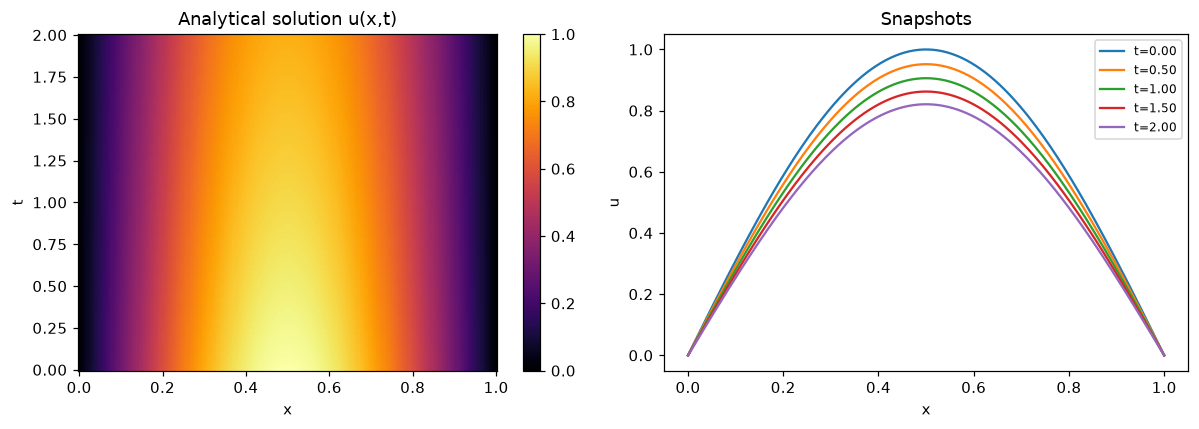

In [5]:

# Quick look at the analytical solution
x_plot = np.linspace(0, CONFIG["L"], 201)
t_plot = np.linspace(0, CONFIG["T"], 200)
U_ana_grid = analytical_solution(x_plot, t_plot, CONFIG)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].pcolormesh(x_plot, t_plot, U_ana_grid, shading="auto", cmap="inferno")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t"); axes[0].set_title("Analytical solution u(x,t)")
fig.colorbar(im, ax=axes[0])

snapshot_times = np.linspace(0, CONFIG["T"], 5)
for tv in snapshot_times:
    axes[1].plot(x_plot, analytical_solution(x_plot, [tv], CONFIG)[0], label=f"t={tv:.2f}")
axes[1].set_xlabel("x"); axes[1].set_ylabel("u"); axes[1].set_title("Snapshots")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()



## 3. Finite Difference Method (FDM)

Discretize $x$ into `nx` points ($dx = L/(n_x-1)$) and $t$ into `nt` steps ($dt = T/n_t$), and let
$r = \alpha\, dt / dx^2$.

- **Explicit (FTCS)**: $u_i^{n+1} = u_i^n + r\left(u_{i+1}^n - 2u_i^n + u_{i-1}^n\right)$.
  Simple, one line per step, but only **conditionally stable**: needs $r \le 0.5$.
- **Implicit (Crank–Nicolson)**: averages the diffusion term between time levels $n$ and $n+1$,
  giving a tridiagonal system to solve at every step. **Unconditionally stable** and second-order
  accurate in both space and time.


In [6]:

def fdm_solve(config):
    L, alpha, T = config["L"], config["alpha"], config["T"]
    nx, nt, scheme = config["fdm"]["nx"], config["fdm"]["nt"], config["fdm"]["scheme"]
    dx = L / (nx - 1)
    dt = T / nt
    r = alpha * dt / dx**2
    x = np.linspace(0, L, nx)
    t = np.linspace(0, T, nt + 1)

    U = np.zeros((nt + 1, nx))
    U[0, :] = ic_np(x, config)
    U[:, 0] = config["bc_left"]
    U[:, -1] = config["bc_right"]

    if scheme == "explicit":
        if r > 0.5:
            print(f"WARNING: explicit FTCS is unstable for r={r:.3f} > 0.5. "
                  f"Increase nt or decrease nx.")
        for n in range(nt):
            U[n+1, 1:-1] = U[n, 1:-1] + r * (U[n, 2:] - 2*U[n, 1:-1] + U[n, :-2])
            U[n+1, 0], U[n+1, -1] = config["bc_left"], config["bc_right"]

    elif scheme == "implicit":
        m = nx - 2
        ab = np.zeros((3, m))          # banded matrix for solve_banded: (1 + r) on diag, -r/2 off-diag
        ab[0, 1:] = -r / 2
        ab[1, :] = 1 + r
        ab[2, :-1] = -r / 2
        for n in range(nt):
            rhs = U[n, 1:-1] + (r / 2) * (U[n, 2:] - 2*U[n, 1:-1] + U[n, :-2])
            rhs[0]  += (r / 2) * config["bc_left"]
            rhs[-1] += (r / 2) * config["bc_right"]
            U[n+1, 1:-1] = solve_banded((1, 1), ab, rhs)
            U[n+1, 0], U[n+1, -1] = config["bc_left"], config["bc_right"]
    else:
        raise ValueError("fdm.scheme must be 'explicit' or 'implicit'")

    return x, t, U, r


x_fdm, t_fdm, U_fdm, r_val = fdm_solve(CONFIG)
print(f"FDM grid: nx={CONFIG['fdm']['nx']}, nt={CONFIG['fdm']['nt']}, r=alpha*dt/dx^2={r_val:.4f}")

U_ana_on_fdm_grid = analytical_solution(x_fdm, t_fdm, CONFIG)
fdm_err = np.abs(U_fdm - U_ana_on_fdm_grid)
print(f"FDM vs analytical -> max abs error: {fdm_err.max():.3e}, mean abs error: {fdm_err.mean():.3e}")


FDM grid: nx=101, nt=4000, r=alpha*dt/dx^2=0.0500
FDM vs analytical -> max abs error: 9.329e-06, mean abs error: 3.143e-06


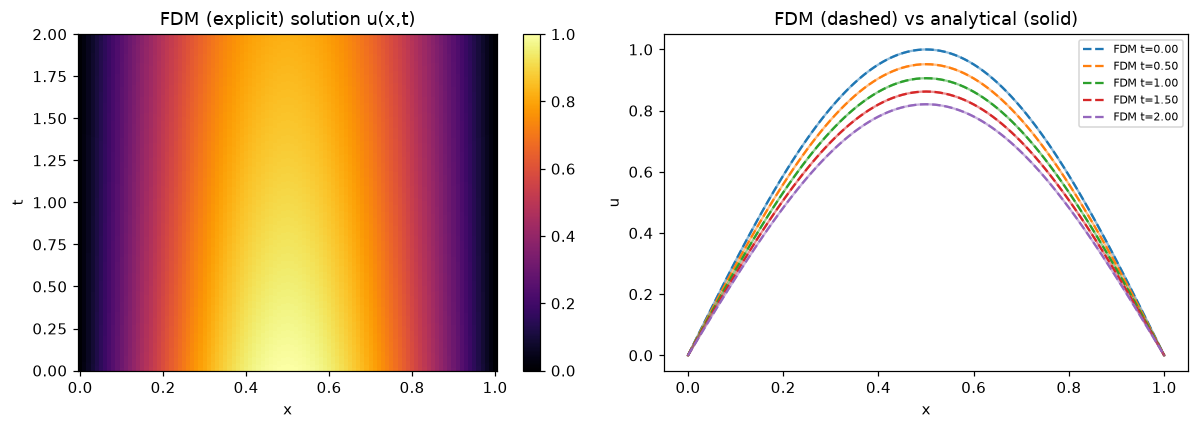

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].pcolormesh(x_fdm, t_fdm, U_fdm, shading="auto", cmap="inferno")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")
axes[0].set_title(f"FDM ({CONFIG['fdm']['scheme']}) solution u(x,t)")
fig.colorbar(im, ax=axes[0])

for tv in snapshot_times:
    idx = np.argmin(np.abs(t_fdm - tv))
    axes[1].plot(x_fdm, U_fdm[idx], "--", label=f"FDM t={t_fdm[idx]:.2f}")
    axes[1].plot(x_plot, analytical_solution(x_plot, [tv], CONFIG)[0], alpha=0.5,
                 color=axes[1].lines[-1].get_color())
axes[1].set_xlabel("x"); axes[1].set_ylabel("u")
axes[1].set_title("FDM (dashed) vs analytical (solid)")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()



## 4. Machine Learning: Physics-Informed Neural Network (PINN)

Instead of a grid, we train a small neural network $u_\theta(x, t)$ to approximate the solution
everywhere in the domain. There is **no labeled solution data** — the network only ever sees random
points $(x,t)$ and is trained to make three residuals go to zero, using automatic differentiation to
compute $\partial u/\partial t$, $\partial u/\partial x$, and $\partial^2 u/\partial x^2$ directly from
the network's outputs:

1. **PDE residual** at random interior points: $\mathcal{L}_{pde} = \frac{1}{N}\sum \left(u_t - \alpha u_{xx}\right)^2$
2. **Initial-condition loss** at random points with $t=0$: $\mathcal{L}_{ic} = \frac{1}{N}\sum \left(u_\theta(x,0) - f(x)\right)^2$
3. **Boundary-condition loss** at random points with $x=0$ or $x=L$: $\mathcal{L}_{bc} = \frac{1}{N}\sum \left(u_\theta(0,t) - g_0\right)^2 + \left(u_\theta(L,t) - g_L\right)^2$

Total loss: $\mathcal{L} = w_{pde}\mathcal{L}_{pde} + w_{ic}\mathcal{L}_{ic} + w_{bc}\mathcal{L}_{bc}$,
minimized with Adam. `tanh` (or another smooth activation) is used because the network must be twice
differentiable in $x$.


In [8]:

ACTIVATIONS = {"tanh": nn.Tanh, "relu": nn.ReLU, "silu": nn.SiLU, "sigmoid": nn.Sigmoid}


class PINN(nn.Module):
    def __init__(self, hidden_layers=4, neurons=32, activation="tanh"):
        super().__init__()
        act = ACTIVATIONS[activation]
        layers = [nn.Linear(2, neurons), act()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(neurons, neurons), act()]
        layers += [nn.Linear(neurons, 1)]
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


def train_pinn(config, verbose_every=500):
    torch.manual_seed(config["pinn"]["seed"])
    L, alpha, T = config["L"], config["alpha"], config["T"]
    pc = config["pinn"]
    net = PINN(pc["hidden_layers"], pc["neurons"], pc["activation"])
    opt = torch.optim.Adam(net.parameters(), lr=pc["lr"])

    n_f, n_ic, n_bc = pc["n_collocation"], pc["n_ic"], pc["n_bc"]
    loss_history = []

    for epoch in range(pc["epochs"]):
        opt.zero_grad()

        # --- PDE residual at random interior collocation points ---
        x_f = (torch.rand(n_f, 1) * L).requires_grad_(True)
        t_f = (torch.rand(n_f, 1) * T).requires_grad_(True)
        u_f = net(x_f, t_f)
        u_t  = torch.autograd.grad(u_f, t_f, grad_outputs=torch.ones_like(u_f), create_graph=True)[0]
        u_x  = torch.autograd.grad(u_f, x_f, grad_outputs=torch.ones_like(u_f), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        loss_pde = ((u_t - alpha * u_xx) ** 2).mean()

        # --- Initial condition ---
        x_ic = torch.rand(n_ic, 1) * L
        t_ic = torch.zeros(n_ic, 1)
        loss_ic = ((net(x_ic, t_ic) - ic_function(x_ic, config)) ** 2).mean()

        # --- Boundary conditions ---
        t_bc = torch.rand(n_bc, 1) * T
        loss_bc = ((net(torch.zeros(n_bc, 1), t_bc) - config["bc_left"]) ** 2).mean() + \
                  ((net(torch.full((n_bc, 1), L), t_bc) - config["bc_right"]) ** 2).mean()

        loss = pc["w_pde"] * loss_pde + pc["w_ic"] * loss_ic + pc["w_bc"] * loss_bc
        loss.backward()
        opt.step()
        loss_history.append((loss.item(), loss_pde.item(), loss_ic.item(), loss_bc.item()))

        if verbose_every and epoch % verbose_every == 0:
            print(f"epoch {epoch:5d}  loss={loss.item():.3e}  "
                  f"pde={loss_pde.item():.3e}  ic={loss_ic.item():.3e}  bc={loss_bc.item():.3e}")

    return net, np.array(loss_history)


pinn_net, loss_history = train_pinn(CONFIG)


epoch     0  loss=6.562e+00  pde=1.255e-02  ic=6.238e-01  bc=3.110e-02
epoch   500  loss=2.891e-02  pde=7.071e-03  ic=1.625e-03  bc=5.592e-04
epoch  1000  loss=8.645e-03  pde=1.426e-03  ic=5.911e-04  bc=1.307e-04
epoch  1500  loss=4.686e-03  pde=3.210e-04  ic=1.617e-04  bc=2.748e-04
epoch  2000  loss=3.997e-04  pde=1.458e-04  ic=1.923e-05  bc=6.153e-06
epoch  2500  loss=8.436e-04  pde=1.365e-04  ic=1.653e-05  bc=5.418e-05
epoch  3000  loss=3.232e-04  pde=1.344e-04  ic=6.280e-06  bc=1.260e-05
epoch  3500  loss=3.427e-03  pde=1.015e-04  ic=9.780e-05  bc=2.347e-04
epoch  4000  loss=2.193e-03  pde=1.007e-04  ic=5.018e-05  bc=1.590e-04
epoch  4500  loss=1.840e-04  pde=8.581e-05  ic=4.328e-06  bc=5.489e-06
epoch  5000  loss=2.395e-04  pde=8.548e-05  ic=2.947e-06  bc=1.245e-05
epoch  5500  loss=3.447e-04  pde=9.023e-05  ic=6.032e-06  bc=1.941e-05


PINN vs analytical -> max abs error: 9.846e-03, mean abs error: 3.469e-03


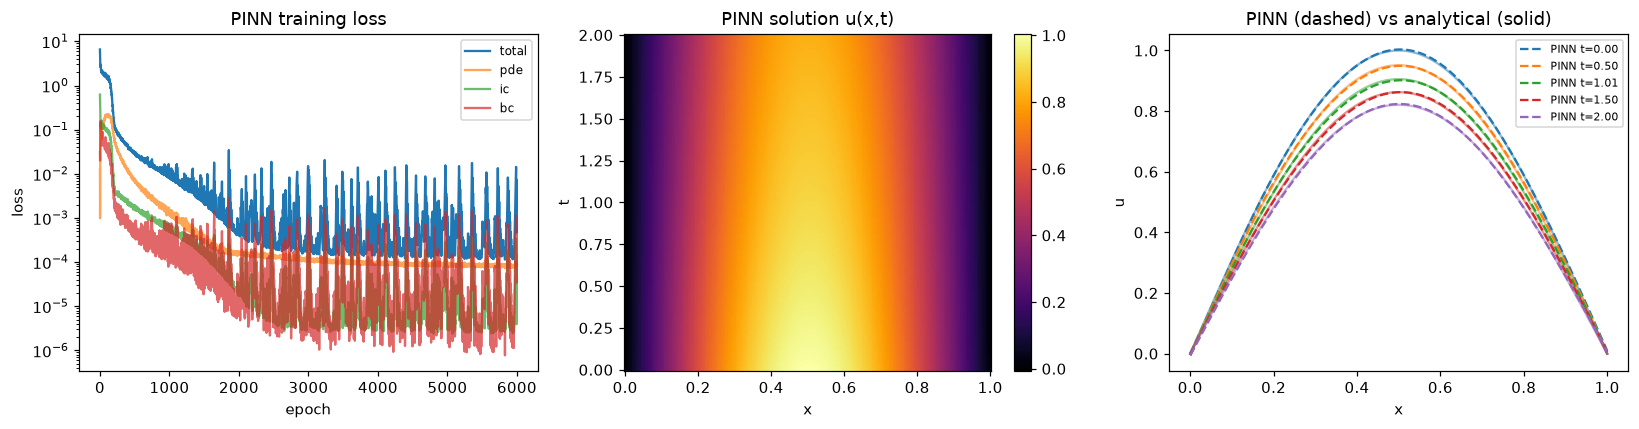

In [9]:

def evaluate_pinn(net, x, t):
    # Evaluate a trained PINN on a grid, returns array of shape (len(t), len(x)).
    net.eval()
    with torch.no_grad():
        x_t = torch.tensor(np.asarray(x, dtype=np.float64)).reshape(-1, 1)
        U = np.zeros((len(t), len(x)))
        for i, tv in enumerate(t):
            t_col = torch.full((len(x), 1), float(tv), dtype=torch.float64)
            U[i, :] = net(x_t, t_col).numpy().flatten()
    return U


U_pinn_grid = evaluate_pinn(pinn_net, x_plot, t_plot)
pinn_err = np.abs(U_pinn_grid - U_ana_grid)
print(f"PINN vs analytical -> max abs error: {pinn_err.max():.3e}, mean abs error: {pinn_err.mean():.3e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history[:, 0], label="total")
axes[0].plot(loss_history[:, 1], label="pde", alpha=0.7)
axes[0].plot(loss_history[:, 2], label="ic", alpha=0.7)
axes[0].plot(loss_history[:, 3], label="bc", alpha=0.7)
axes[0].set_yscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("PINN training loss"); axes[0].legend(fontsize=8)

im = axes[1].pcolormesh(x_plot, t_plot, U_pinn_grid, shading="auto", cmap="inferno")
axes[1].set_xlabel("x"); axes[1].set_ylabel("t"); axes[1].set_title("PINN solution u(x,t)")
fig.colorbar(im, ax=axes[1])

for tv in snapshot_times:
    idx = np.argmin(np.abs(t_plot - tv))
    axes[2].plot(x_plot, U_pinn_grid[idx], "--", label=f"PINN t={t_plot[idx]:.2f}")
    axes[2].plot(x_plot, U_ana_grid[idx], alpha=0.5, color=axes[2].lines[-1].get_color())
axes[2].set_xlabel("x"); axes[2].set_ylabel("u")
axes[2].set_title("PINN (dashed) vs analytical (solid)")
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()



## 5. Side-by-side comparison of all three methods


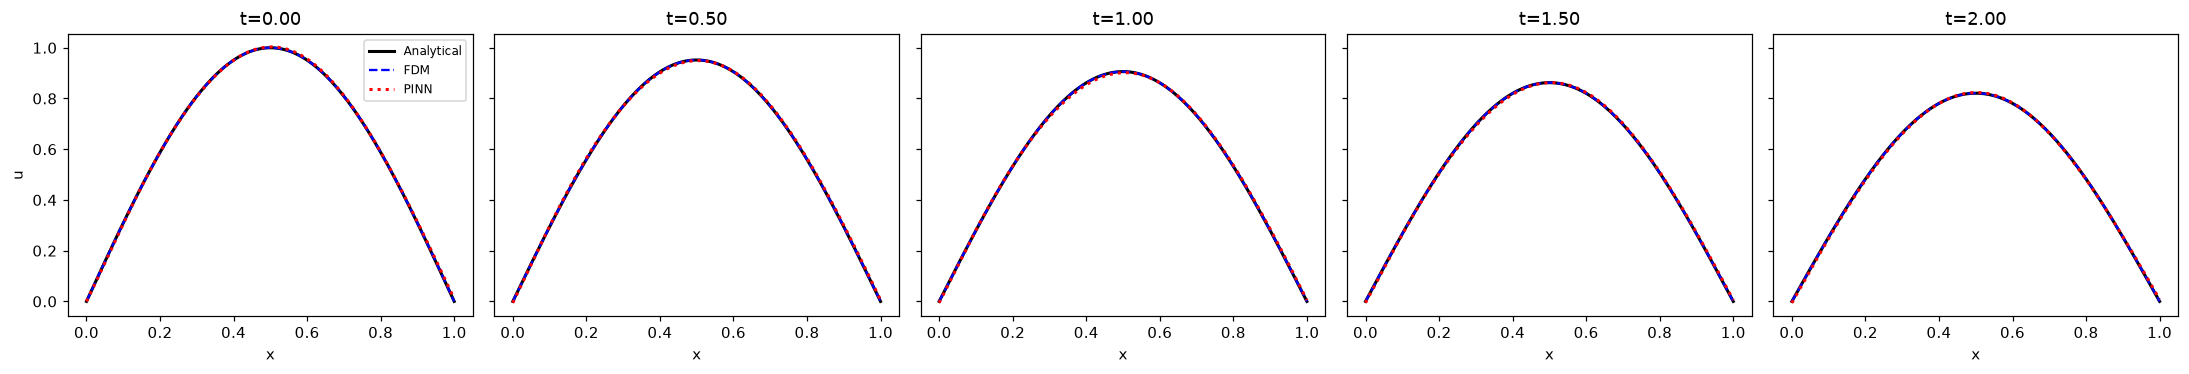

=== Error summary (vs analytical) ===
FDM  (explicit) : max=9.329e-06   mean=3.143e-06
PINN                : max=9.846e-03   mean=3.469e-03


In [10]:

fig, axes = plt.subplots(1, len(snapshot_times), figsize=(4*len(snapshot_times), 3.5), sharey=True)
for ax, tv in zip(axes, snapshot_times):
    ax.plot(x_plot, analytical_solution(x_plot, [tv], CONFIG)[0], "k-", lw=2, label="Analytical")
    idx_fdm = np.argmin(np.abs(t_fdm - tv))
    ax.plot(x_fdm, U_fdm[idx_fdm], "b--", label="FDM")
    idx_pinn = np.argmin(np.abs(t_plot - tv))
    ax.plot(x_plot, U_pinn_grid[idx_pinn], "r:", lw=2, label="PINN")
    ax.set_title(f"t={tv:.2f}"); ax.set_xlabel("x")
axes[0].set_ylabel("u"); axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("=== Error summary (vs analytical) ===")
print(f"FDM  ({CONFIG['fdm']['scheme']:>8s}) : max={fdm_err.max():.3e}   mean={fdm_err.mean():.3e}")
print(f"PINN                : max={pinn_err.max():.3e}   mean={pinn_err.mean():.3e}")



## 6. Ideas for further experiments

All you generally need to change is the `CONFIG` dictionary in Section 1, then re-run the notebook:

- **Different initial condition**: switch `ic_type` to `"gaussian"` (a localized heat pulse) or `"step"`
  (a discontinuous block — notice how the analytical series needs more `n_modes` to represent the jump
  well, i.e. Gibbs phenomenon, and how the PINN handles the discontinuity).
- **Non-zero boundary values**: set `bc_left`/`bc_right` to different constants and watch the system
  relax toward the linear steady-state profile.
- **Faster/slower diffusion**: increase/decrease `alpha`.
- **Break the explicit FDM scheme on purpose**: increase `fdm.nt` down (fewer steps) or `fdm.nx` up
  (finer space) until `r > 0.5` and see the instability the code warns you about; compare with
  `"implicit"`, which stays stable.
- **PINN architecture/training**: try fewer/more `hidden_layers` or `neurons`, a different
  `activation`, more `epochs`, or re-balance `w_pde`/`w_ic`/`w_bc` — a common failure mode is the PDE
  loss dropping while IC/BC losses stay high (or vice versa); the printed per-epoch losses make this
  easy to diagnose.
- **Data-driven alternative**: instead of a physics-informed loss, you could instead generate training
  data from the FDM solver (`fdm_solve`) and train a plain supervised regression network
  (`u_theta(x,t) -> u`) on `(x, t, u)` triples — a nice comparison of *"learning the physics"* (PINN,
  no solution data needed) vs *"learning from data"* (supervised, needs a solver or measurements to
  generate labels).
- **Extending to 2D/3D**: the same PINN idea generalizes directly — add spatial dimensions as extra
  network inputs and extra `autograd.grad` calls for the additional second derivatives in the residual.
